In [4]:
%store -r df

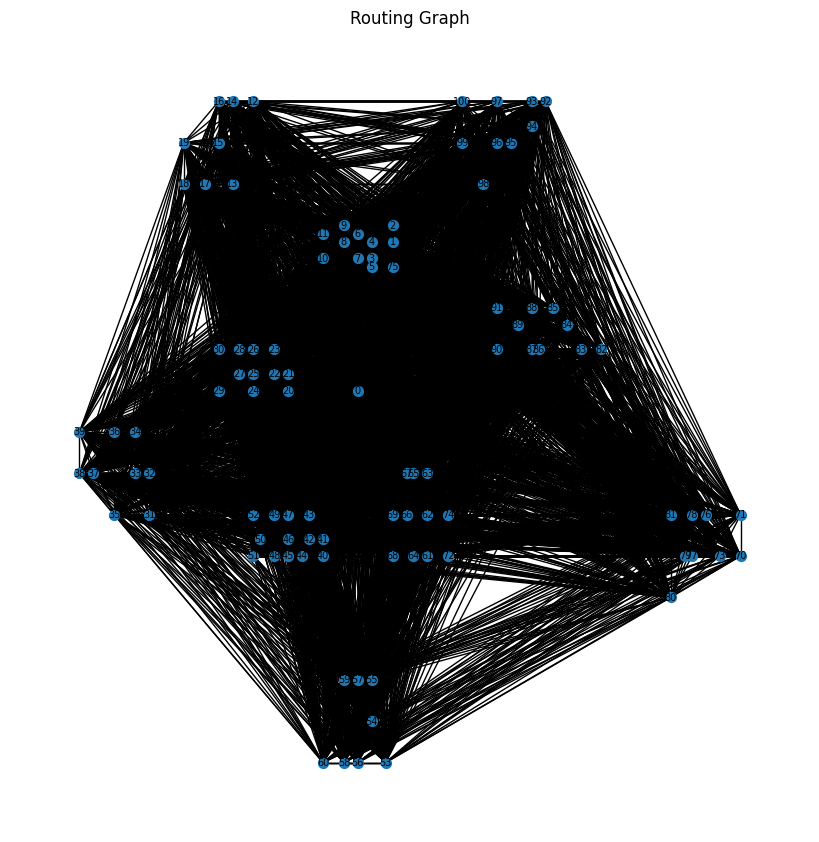

In [6]:
import matplotlib.pyplot as plt

from app.graph.graph_builder import build_graph

import networkx as nx

G = build_graph(df)

pos = nx.get_node_attributes(G, "pos")

plt.figure(figsize=(8,8))

nx.draw(
    G,
    pos,
    node_size=50,
    with_labels=True,
    font_size=7
)

plt.title("Routing Graph")

plt.show()

In [18]:
import pandas as pd

edges_df = pd.DataFrame(
    [
        {
            "from": u,
            "to": v,
            "weight": data["weight"]
        }
        for u, v, data in G.edges(data=True)
    ]
)

edges_df

,from,to,weight
0,0,1,18.681542
1,0,2,20.615528
2,0,3,16.124515
3,0,4,18.110770
4,0,5,15.132746
...,...,...,...
5045,97,99,7.071068
5046,97,100,5.000000
5047,98,99,5.830952
5048,98,100,10.440307


In [3]:
from app.graph.distance_matrix import build_distance_matrix

D = build_distance_matrix(G)

D.shape

(101, 101)

In [4]:
D[:5, :5]

array([[ 0.        , 18.68154169, 20.61552813, 16.1245155 , 18.11077028],
       [18.68154169,  0.        ,  2.        ,  3.60555128,  3.        ],
       [20.61552813,  2.        ,  0.        ,  5.        ,  3.60555128],
       [16.1245155 ,  3.60555128,  5.        ,  0.        ,  2.        ],
       [18.11077028,  3.        ,  3.60555128,  2.        ,  0.        ]])

In [6]:
from app.optimization.tsp import create_binary_variables

variables = create_binary_variables(5)

variables[:10]

[(0, 0),
 (0, 1),
 (0, 2),
 (0, 3),
 (0, 4),
 (1, 0),
 (1, 1),
 (1, 2),
 (1, 3),
 (1, 4)]

In [8]:
small_df = df.iloc[:3]
small_df

,id,x,y,demand,ready_time,due_date,service_time
0,0,40.0,50.0,0.0,0.0,1236.0,0.0
1,1,45.0,68.0,10.0,912.0,967.0,90.0
2,2,45.0,70.0,30.0,825.0,870.0,90.0


In [9]:
from app.graph.graph_builder import build_graph
from app.graph.distance_matrix import build_distance_matrix

G_small = build_graph(small_df)

D_small = build_distance_matrix(G_small)

In [8]:
%store D_small

Stored 'D_small' (ndarray)
